In [1]:
" Get all the important packages to extract the data from the data set"

import pandas as pd
from collections import Counter
from collections import Counter
import numpy as np
from ase import Atoms
from dscribe.descriptors import SOAP
import numpy as np
import pandas as pd
import numpy as np
from pymatgen.core import Element
from mendeleev import element
import ast
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

In [2]:
" Creat all the nessary dataframes that we wanted to investigate at the beginning"



df_ABC3 = pd.read_csv("../ABC3_filtered.csv", usecols= ['formula_pretty','elements', 'band_gap','energy_above_hull','formation_energy_per_atom','density',"structure.sites"])
df_ABC3.to_csv("df_ABC3.csv", index=False)
df_ABC3 = pd.read_csv("df_ABC3.csv")

df_A2BCX6 = pd.read_csv("../A2BCX6_filtered.csv", usecols= ['formula_pretty','elements', 'band_gap','energy_above_hull','formation_energy_per_atom','density',"structure.sites"])
df_A2BCX6.to_csv("df_A2BCX6.csv", index=False)
df_A2BCX6 = pd.read_csv("df_A2BCX6.csv")

df_raw = pd.concat([df_ABC3, df_A2BCX6], axis=0,ignore_index=True)
df_raw.to_csv("df_raw.csv", index=False) 
df_raw = pd.read_csv("df_raw.csv")

df_leadfree_raw = df_raw[df_raw['formula_pretty'].apply(lambda x: 'Pb' not in x if isinstance(x, str) else False)]
df_leadfree_raw.to_csv("df_leadfree_raw.csv", index=False)
df_leadfree_raw = pd.read_csv("df_leadfree_raw.csv")

df_ABC3_leadfree = df_ABC3[df_ABC3['formula_pretty'].apply(lambda x: 'Pb' not in x if isinstance(x, str) else False)]
df_ABC3_leadfree.to_csv("df_ABC3_leadfree_raw.csv", index=False)
df_ABC3_leadfree_raw = pd.read_csv("df_ABC3_leadfree_raw.csv")

df_A2BCX6_leadfree = df_A2BCX6[df_A2BCX6['formula_pretty'].apply(lambda x: 'Pb' not in x if isinstance(x, str) else False)]
df_A2BCX6_leadfree.to_csv("df_A2BCX6_leadfree_raw.csv", index=False)
df_A2BCX6_leadfree_raw = pd.read_csv("df_A2BCX6_leadfree_raw.csv")

# saving and reading every dataframe becuase I got wierd type issues and I tried to fix it but couldnt so I just hard coded it 




In [3]:

elemental_abundance = {
    'Ac' : 0.000000000055,
    'Ag' : 0.075,
    'Al' : 82300,
    'Ar' : 3.5,
    'As' : 1.8,
    'At' : 0.000000000005,
    'Au' : 0.004,
    'B' : 10,
    'Ba' : 425,
    'Be' : 2.8,
    'Bi' : 0.0085,
    'Br' : 2.4,
    'C' : 200,
    'Ca' : 41500,
    'Cd' : 0.15,
    'Ce' : 66.5,
    'Cl' : 145,
    'Co' : 25,
    'Cr' : 102,
    'Cs' : 3,
    'Cu' : 60,
    'Dy' : 5.2,
    'Er' : 3.5,
    'Eu' : 2,
    'F' : 585,
    'Fe' : 56300,
    'Fr' : 0.000000000005,
    'Ga' : 19,
    'Gd' : 6.2,
    'Ge' : 1.5,
    'H' : 1400,
    'He' : 0.008,
    'Hf' : 3.0,
    'Hg' : 0.085,
    'Ho' : 1.3,
    'I' : 0.45,
    'In' : 0.25,
    'Ir' : 0.001,
    'K' : 20900,
    'Kr' : 0.0001,
    'La' : 39,
    'Li' : 20,
    'Lu' : 0.8,
    'Mg' : 23300,
    'Mn' : 950,
    'Mo' : 1.2,
    'N' : 19,
    'Na' : 23600,
    'Nb' : 20,
    'Nd' : 41.5,
    'Ne' : 0.005,
    'Ni' : 84,
    'Np' : 0.00000000005,
    'O' : 461000,
    'Os' : 0.0015,
    'P' : 1050,
    'Pa' : 0.00000000005,
    'Pb' : 14,
    'Pd' : 0.015,
    'Pm' : 0.00000000005,
    'Po' : 0.00000000002,
    'Pr' : 9.2,
    'Pt' : 0.005,
    'Pu' : 0.00000000005,
    'Ra' : 0.0000009,
    'Rb' : 90,
    'Re' : 0.0007,
    'Rh' : 0.001,
    'Rn' : 0.0000000000004,
    'Ru' : 0.001,
    'S' : 350,
    'Sb' : 0.2,
    'Sc' : 22,
    'Se' : 0.05,
    'Si' : 282000,
    'Sm' : 7.05,
    'Sn' : 2.3,
    'Sr' : 370,
    'Ta' : 2.0,
    'Tb' : 1.2,
    'Tc' : 0.0000000005,
    'Te' : 0.001,
    'Th' : 9.6,
    'Ti' : 5650,
    'Tl' : 0.85,
    'Tm' : 0.52,
    'U' : 2.7,
    'V' : 120,
    'W' : 1.25,
    'Xe' : 0.00003,
    'Y' : 33,
    'Yb' : 3.2,
    'Zn' : 70,
    'Zr' : 165
}

# Read in Dataframe
# df = pd.read_csv('df_soap.csv')


def convert_string_to_list(element_string):
    try:
        return ast.literal_eval(element_string)
    except (SyntaxError, ValueError):
        return []  # Or handle errors as appropriate

# Define your abundance threshold
abundance_threshold = 10  # Example threshold in ppm

def is_abundant_perovskite(elements, abundance_data, threshold):
    """
    Checks if all elements in a list are above the abundance threshold.

    Args:
        elements (list): A list of element symbols (e.g., ['Ni', 'O', 'Sr', 'W']).
        abundance_data (dict): A dictionary of elemental abundances (e.g., {'Ni': 18.0, ...}).
        threshold (float): The minimum abundance threshold.

    Returns:
        bool: True if all elements are above the threshold, False otherwise.
    """
    for element in elements:
        if element in abundance_data and abundance_data[element] <= threshold:
            return False
        elif element not in abundance_data:
            print(f"Warning: Abundance data not found for element '{element}'. Assuming it's not abundant.")
            return False  # Or you could choose to handle missing data differently
    return True

# if 'elements' in df.columns:
#     df['elements'] = df['elements'].apply(convert_string_to_list)

#     # Apply the function to each row of the DataFrame
#     abundant_mask = df['elements'].apply(lambda x: is_abundant_perovskite(x, elemental_abundance, abundance_threshold))

#     # Filter the DataFrame using the boolean mask
#     df_abundant_perovskites = df[abundant_mask]

#     print(f"Original DataFrame shape: {df.shape}")
#     print(f"Filtered DataFrame shape (threshold = {abundance_threshold} ppm): {df_abundant_perovskites.shape}")
#     # Now 'abundant_perovskites_df' contains only the structures where all elements
#     # have a natural abundance greater than or equal to the threshold.
#     # print(abundant_perovskites_df.head())
# else:
#     print("Error: The 'elements' column was not found in the DataFrame.")

In [4]:
" this part creates the dataframes wit hall the physcal properties that we need"

missing_fusion_heats = {
    "As": 24.44,  # kJ/mol
    "O" : 0.44,
    "N" : 0.72,
    "C" : 117,
    "Ru" : 38.59,
    "Tb" : 10.15,
    "Gd" : 10.05,
    "Dy" : 11.06,
    "Eu" : 9.21,
    "Ho" : 17.0,
    "Er" : 19.9,
    "Lu" : 22,
    "Tm" : 16.84
}

from mendeleev import element

def get_fusion_heat(element_symbol):
    elmt = element(element_symbol)
    if elmt.fusion_heat is None and element_symbol in missing_fusion_heats:
        return missing_fusion_heats[element_symbol]
    elif elmt.fusion_heat is None and element_symbol not in missing_fusion_heats:
        print(elmt.name, "is missing fusion heat value")
    else:
        return elmt.fusion_heat

missing_evaporation_heats = {
    "O" : 6.82, # kJ/mol
    "N" : 5.58,
    "C" : 715,
    "Ru" : 619,
    "Tb" : 391
}

from mendeleev import element

def get_evaporation_heat(element_symbol):
    elmt = element(element_symbol)
    if elmt.evaporation_heat is None and element_symbol in missing_evaporation_heats:
        return missing_evaporation_heats[element_symbol]
    else:
        return elmt.evaporation_heat

missing_specific_heats = {
    "Pa" : 99.1,
    "Tc" : 63
}

def get_specific_heat(element_symbol):
    elmt = element(element_symbol)
    if elmt.specific_heat is None and element_symbol in missing_specific_heats:
        return missing_specific_heats[element_symbol]
    else:
        return elmt.specific_heat

def get_boiling_point(element_symbol):
    elmt = element(element_symbol)
    if element_symbol == "Pa":
        return 4000
    elif element_symbol == "P":
        return 550
    else:
        return elmt.boiling_point
    


def get_atomic_radius_calculated(elmt_pymatgen_temp):
    atomic_radius_calculated_temp = elmt_pymatgen_temp.atomic_radius_calculated
    if atomic_radius_calculated_temp == None:
        return elmt_pymatgen_temp.atomic_radius
    else :
      return atomic_radius_calculated_temp

def get_density_of_solid(elmt_pymatgen_temp):
    density_of_solid_temp = elmt_pymatgen_temp.density_of_solid
    if density_of_solid_temp == None:
        return elmt_pymatgen_temp.atomic_mass / elmt_pymatgen_temp.molar_volume *1000
    else :
      return density_of_solid_temp

In [5]:
#create dictionary with the values for all elements (so that the loop over all formulas is faster) (takes approx 4 minutes now)


#find all elements in the csv file to create input for dictionary creation
# elements_list = pd.read_csv('df.csv', usecols= ['elements'])
  # Select only the 'elements' column

def get_elemental_properties(df):
    elements_list = df[['elements']]
    elements_vector = []
    for index in elements_list.index: # Iterate over DataFrame index to get row
        formula = elements_list.loc[index, 'elements'] # Access element string using loc
        formula = ast.literal_eval(formula) # Safely evaluate string as list
        for elmt in formula:
            elements_vector.append(elmt)

    elements_vector = pd.Series(elements_vector).drop_duplicates().tolist() # Deduplicate elements


    #loop over the found unique elements and define the needed properties
    elemental_properties = {}  #dictionary to be filled

    for symbol in elements_vector:
        #define strings as "elements"
        elmt_pymatgen = Element(symbol)
        elmt_mendeleev = element(symbol)

        properties = {
            'atomic_mass': elmt_pymatgen.atomic_mass,
            'Z': elmt_pymatgen.Z,
            'group': elmt_pymatgen.group,
            'fusion_heat': get_fusion_heat(symbol),  # Use custom function
            'evaporation_heat': get_evaporation_heat(symbol),  # Use custom function
            'specific_heat': get_specific_heat(symbol), # Use custom function
            'row': elmt_pymatgen.row,
            'mendeleev_no': elmt_pymatgen.mendeleev_no,
            'iupac_ordering': elmt_pymatgen.iupac_ordering,
            'average_ionic_radius': elmt_pymatgen.average_ionic_radius,
            'atomic_radius': elmt_pymatgen.atomic_radius,
            'atomic_radius_calculated': get_atomic_radius_calculated(elmt_pymatgen), # Use custom function
            'van_der_waals_radius': elmt_pymatgen.van_der_waals_radius,
            'X': elmt_pymatgen.X,
            'electron_affinity': elmt_pymatgen.electron_affinity,
            'ionization_energy': elmt_pymatgen.ionization_energy,
        #    'valence': elmt_pymatgen.valence[1],
            'density_of_solid': get_density_of_solid(elmt_pymatgen), # Use custom function
            'molar_volume': elmt_pymatgen.molar_volume,
            'boiling_point': get_boiling_point(symbol), # Use custom function
            'melting_point': elmt_pymatgen.melting_point,
            'thermal_conductivity': elmt_pymatgen.thermal_conductivity

        }

        elemental_properties[symbol] = properties  # For dictionary
    return elemental_properties



    


In [6]:

def get_df (df_1, elemental_properties):
  "Input: dataframe with the data from the csv file, dictionary with the elemental properties"
  "Output: dataframe with the data from the csv file and the elemental/physical properties"

  
  df = df_1.copy()
  #select only te importnat columns from the datafram:
  df = df[['formula_pretty','elements', 'band_gap','energy_above_hull','formation_energy_per_atom','density','structure.sites']]
  index = -1
  for formula in df["elements"]:
    index += 1
    #reformat to list
    elements = ast.literal_eval(formula)

    #calculate property and mean/sd
    atomic_mass = []
    Z = []
    group = []
    row = []
    mendeleev_no = []
    iupac_ordering = []
    average_ionic_radius = []
    atomic_radius = []
    atomic_radius_calculated = []
    van_der_waals_radius = []
    X = []
    electron_affinity = []
    ionization_energy = []
    valence = []
    atomic_mass = []
    density_of_solid = []
    molar_volume = []
    fusion_heat = []
    evaporation_heat = []
    specific_heat = []

#use the library to assign the properties
    for elmt in elements:

      atomic_mass.append(elemental_properties[elmt]['atomic_mass'])
      Z.append(elemental_properties[elmt]['Z'])
      group.append(elemental_properties[elmt]['group'])
      row.append(elemental_properties[elmt]['row'])
      mendeleev_no.append(elemental_properties[elmt]['mendeleev_no'])
      iupac_ordering.append(elemental_properties[elmt]['iupac_ordering'])
      average_ionic_radius.append(elemental_properties[elmt]['average_ionic_radius'])
      atomic_radius.append(elemental_properties[elmt]['atomic_radius'])
      atomic_radius_calculated.append(elemental_properties[elmt]['atomic_radius_calculated'])
      van_der_waals_radius.append(elemental_properties[elmt]['van_der_waals_radius'])
      X.append(elemental_properties[elmt]['X'])
      electron_affinity.append(elemental_properties[elmt]['electron_affinity'])
      ionization_energy.append(elemental_properties[elmt]['ionization_energy'])
      #valence.append(elmt.valence[1])
      density_of_solid.append(elemental_properties[elmt]['density_of_solid'])
      molar_volume.append(elemental_properties[elmt]['molar_volume'])
      fusion_heat.append(elemental_properties[elmt]['fusion_heat'])
      evaporation_heat.append(elemental_properties[elmt]['evaporation_heat'])
      specific_heat.append(elemental_properties[elmt]['specific_heat'])

    mean_atomic_mass = np.mean(atomic_mass)
    std_atomic_mass = np.std(atomic_mass)
    mean_Z = np.mean(Z)
    std_Z = np.std(Z)
    mean_group = np.mean(group)
    std_group = np.std(group)
    mean_row = np.mean(row)
    std_row = np.std(row)
    mean_mendeleev_no = np.mean(mendeleev_no)
    std_mendeleev_no = np.std(mendeleev_no)
    mean_iupac_ordering = np.mean(iupac_ordering)
    std_iupac_ordering = np.std(iupac_ordering)
    mean_average_ionic_radius = np.mean(average_ionic_radius)
    std_average_ionic_radius = np.std(average_ionic_radius)
    mean_atomic_radius = np.mean(atomic_radius)
    std_atomic_radius = np.std(atomic_radius)
    mean_atomic_radius_calculated = np.mean(atomic_radius_calculated)
    std_atomic_radius_calculated = np.std(atomic_radius_calculated)
    mean_van_der_waals_radius = np.mean(van_der_waals_radius)
    std_van_der_waals_radius = np.std(van_der_waals_radius)
    mean_X = np.mean(X)
    std_X = np.std(X)
    mean_electron_affinity = np.mean(electron_affinity)
    std_electron_affinity = np.std(electron_affinity)
    mean_ionization_energy = np.mean(ionization_energy)
    std_ionization_energy = np.std(ionization_energy)
    #mean_valence = np.mean(valence)   ##valence not working yet because of ambiguity
    #std_valence = np.std(valence)
    mean_density_of_solid = np.mean(density_of_solid)
    std_density_of_solid = np.std(density_of_solid)
    mean_molar_volume = np.mean(molar_volume)
    std_molar_volume = np.std(molar_volume)
    mean_fusion_heat = np.mean(fusion_heat)
    std_fusion_heat = np.std(fusion_heat)
    mean_evaporation_heat = np.mean(evaporation_heat)
    std_evaporation_heat = np.std(evaporation_heat)
    mean_specific_heat = np.mean(specific_heat)
    std_specific_heat = np.std(specific_heat)

    #add to dataframe
    df.at[index, 'atom_mass_mean'] = mean_atomic_mass
    df.at[index, 'atom_mass_std'] = std_atomic_mass
    df.at[index, 'Z_mean'] = mean_Z
    df.at[index, 'Z_std'] = std_Z
    df.at[index, 'group_mean'] = mean_group
    df.at[index, 'group_std'] = std_group
    df.at[index, 'row_mean'] = mean_row
    df.at[index, 'row_std'] = std_row
    df.at[index, 'mendeleev_no_mean'] = mean_mendeleev_no
    df.at[index, 'mendeleev_no_std'] = std_mendeleev_no
    df.at[index, 'iupac_ordering_mean'] = mean_iupac_ordering
    df.at[index, 'iupac_ordering_std'] = std_iupac_ordering
    df.at[index, 'average_ionic_radius_mean'] = mean_average_ionic_radius
    df.at[index, 'average_ionic_radius_std'] = std_average_ionic_radius
    df.at[index, 'atomic_radius_mean'] = mean_atomic_radius
    df.at[index, 'atomic_radius_std'] = std_atomic_radius
    df.at[index, 'atomic_radius_calculated_mean'] = mean_atomic_radius_calculated
    df.at[index, 'atomic_radius_calculated_std'] = std_atomic_radius_calculated
    df.at[index, 'van_der_waals_radius_mean'] = mean_van_der_waals_radius
    df.at[index, 'van_der_waals_radius_std'] = std_van_der_waals_radius
    df.at[index, 'X_mean'] = mean_X
    df.at[index, 'X_std'] = std_X
    df.at[index, 'electron_affinity_mean'] = mean_electron_affinity
    df.at[index, 'electron_affinity_std'] = std_electron_affinity
    df.at[index, 'ionization_energy_mean'] = mean_ionization_energy
    df.at[index, 'ionization_energy_std'] = std_ionization_energy
    #df.at[index, 'valence_mean'] = mean_valence
    #df.at[index, 'valence_std'] = std_valence
    df.at[index, 'density_of_solid_mean'] = mean_density_of_solid
    df.at[index, 'density_of_solid_std'] = std_density_of_solid
    df.at[index, 'molar_volume_mean'] = mean_molar_volume
    df.at[index, 'molar_volume_std'] = std_molar_volume
    df.at[index, 'fusion_heat_mean'] = mean_fusion_heat
    df.at[index, 'fusion_heat_std'] = std_fusion_heat
    df.at[index, 'evaporation_heat_mean'] = mean_evaporation_heat
    df.at[index, 'evaporation_heat_std'] = std_evaporation_heat
    df.at[index, 'specific_heat_mean'] = mean_specific_heat
    df.at[index, 'specific_heat_std'] = std_specific_heat
  return df



In [7]:

def get_data (df):
    "Input: dataframe with the data from the csv file, expects the columns 'elements' and 'structure.sites'"
    "Output: dataframe where the columns 'elements' and 'structure.sites' are split into lists of elements and positions and "
    "unnecessary characters are removed"


    df_curated = pd.DataFrame()

    df_curated["Elements"] = df["elements"]
    df_curated["structure_string"] = df["structure.sites"]
    df_curated["structure_string_split"] = None
    

    #Loop over all entries in the dataframe 
    for i in range(df_curated.shape[0]):
        

        df_curated["structure_string_split"].iloc[i] = df_curated["structure_string"].iloc[i].split()
       
        # cleans the structure string and removes all the unnecessary characters
        for j in range(len(df_curated["structure_string_split"].iloc[i])):


            df_curated["structure_string_split"].iloc[i][j] = df_curated["structure_string_split"].iloc[i][j].replace("{","")
            df_curated["structure_string_split"].iloc[i][j] = df_curated["structure_string_split"].iloc[i][j].replace("}","")
            df_curated["structure_string_split"].iloc[i][j] = df_curated["structure_string_split"].iloc[i][j].replace("[","")
            df_curated["structure_string_split"].iloc[i][j] = df_curated["structure_string_split"].iloc[i][j].replace("]","")
            df_curated["structure_string_split"].iloc[i][j] = df_curated["structure_string_split"].iloc[i][j].replace(":","")
            df_curated["structure_string_split"].iloc[i][j] = df_curated["structure_string_split"].iloc[i][j].replace("'","")
            df_curated["structure_string_split"].iloc[i][j] = df_curated["structure_string_split"].iloc[i][j].replace(",","")


        # cleans the elements string and removes all the unnecessary characters
        df_curated["Elements"].iloc[i] = df_curated["Elements"].iloc[i].split(",")
        for k in range(len(df_curated["Elements"].iloc[i])):
            df_curated["Elements"].iloc[i][k] = df_curated["Elements"].iloc[i][k].replace("'", "")
            df_curated["Elements"].iloc[i][k] = df_curated["Elements"].iloc[i][k].replace("[", "")
            df_curated["Elements"].iloc[i][k] = df_curated["Elements"].iloc[i][k].replace("]", "")
            df_curated["Elements"].iloc[i][k] = df_curated["Elements"].iloc[i][k].replace(" ", "")



    print("get data done")
    return df_curated




def split_df (df):
    "Input: dataframe with the following columns: structure_string_split where each elements has 18 entires "
    "This column is generated by the get_data function"
    ""
    "Output: dataframe with a new column 'positions' containing lists of tuples (element, [x, y, z])"
   


    df["positions"] = None

    #loops over all entries in the dataframe
    for i in range(len(df["structure_string_split"])):
        position_i = []
        #loops over all entries in the structure_string_split column, where each element has 18 entries
        # and only extract the relevant items from the list 
        for j in range (0, len(df["structure_string_split"].iloc[i]), 18):
            element = df["structure_string_split"].iloc[i][j+2] # remove trailing comma
            x = float(df["structure_string_split"].iloc[i][j+15])
            y = float(df["structure_string_split"].iloc[i][j+16])
            z = float(df["structure_string_split"].iloc[i][j+17])
            position_i.append((element, [x, y, z]))
        df["positions"].iloc[i] = position_i


    print("split df done")
    return df


def get_ratio(df):
    "Input: pd.datafram with a column 'positions' containing lists of tuples (element, [x, y, z])"
    
    "Output: appends dataframe with a new column 'ratio' containing a sorted dictionary of elements and their ratios"
    
    df["ratio"] = None

    #loops over all entriey in positions
    for i, atom_list in enumerate(df["positions"]):
        elements = [atom[0] for atom in atom_list]
        occurance = Counter(elements)

        counts = np.fromiter(occurance.values(), dtype=int)

        gcd = np.gcd.reduce(counts)


        reduced_occurance = {element: count // gcd for element, count in occurance.items()}

        # Sort by value so largest is last
        sorted_occurrence = dict(sorted(reduced_occurance.items(), key=lambda item: item[1]))

        df["ratio"].iloc[i] = sorted_occurrence

    return df


def get_ase(df):
    "Input : pd.datafram with a column 'positions' containing lists of tuples (element, [x, y, z])"
    "Output: appends dataframe with a new column 'ase' containing ase atoms objects"




    df["ase"] = None  # Optional, for clarity
    for i, row in df.iterrows():
        symbols = [atom[0] for atom in row["positions"]]
        positions = [atom[1] for atom in row["positions"]]
        
        atoms_obj = Atoms(symbols=symbols, positions=positions)
        df.at[i, "ase"] = atoms_obj
    return df


def get_soap(df, r_cut=190.0, n_max=2, l_max=2, sigma=1):
    "Input: pd.datafram with a column 'ase' containing ase atoms objects"
    "Generate a column 'soap' whcih contains a list of all soaps belonging to the strcuture. This column is then split into multiple columns, to finish the data curation"
    "Output: appends dataframe with multiple new columns 'soap1......10000...' containing the soap descriptors"


    unique_species = sorted(set(e for row in df["Elements"] for e in row))

    # Create SOAP descriptor generator
    soap_generator = SOAP(
        species=unique_species,
        r_cut=r_cut,
        n_max=n_max,
        l_max=l_max,
        sigma=sigma,
        periodic=False,
        sparse=False,
        rbf = "gto"
    )

    # Generate and store SOAP descriptors
    soap_list = []
    for atoms in df["ase"]:
        descriptor = soap_generator.create(atoms)
        #this seems to make every soap have the same length
        avg_descriptor = np.mean(descriptor, axis=0) #check if this is the correct way to do it with stehpan 

        soap_list.append(avg_descriptor)

    df["soap"] = soap_list
    return df


def append_soap(df):

    "Input: pandas dataframe, expects the columns 'elements' and 'structure.sites'"
    "this uses all the functions above to add the soaps to the dataframe with the physical properties created in the cell above"
    "Output: dataframe with the soap descriptors appended to the end of the dataframe"

    df_soap = df.copy()
    df_soap = get_data(df_soap)
    df_soap = split_df(df_soap)
    df_soap = get_ase(df_soap)
    df_soap = get_soap(df_soap)
    df["elements"] = df_soap["Elements"] #this overwrites the elements column with the cleaned version (cleaned with get_data)
    df_soap.drop(columns=["Elements","structure_string", "structure_string_split","positions","ase"], inplace=True)
    df = pd.concat([df, df_soap], axis=1)
    df.drop(columns=["structure.sites"], inplace=True)
    soap_array = np.array(df['soap'].to_list())

    # spits the soap array into multiple columns
    soap_columns = [f"soap_{i}" for i in range(soap_array.shape[1])]

    soap_df = pd.DataFrame(soap_array, columns=soap_columns, index=df.index)

    df = df.drop(columns=['soap']).join(soap_df)
    print("append soap done")
  
    return df


def create_df(df):
  
  "Input: pandas dataframe, expects the columns 'elements' and 'structure.sites' for get_elemenal_properties"
  "df[['formula_pretty','elements', 'band_gap','energy_above_hull','formation_energy_per_atom','density','structure.sites']] for get df,"
  ""
  "Output: curated dataframe with the soap descriptors appended to the end of the dataframe"
  df = df.copy()

  elemental_properties = get_elemental_properties(df)

  df = get_df(df,elemental_properties)
  df_soap = append_soap(df)

  print("soap appended")
  return df_soap

# df_soap = create_df(df)


# df_soap



In [8]:
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np
import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.Chem import rdFingerprintGenerator
from matplotlib import pyplot as plt
from sklearn.model_selection import GridSearchCV, KFold, cross_val_score, RandomizedSearchCV, learning_curve
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestRegressor
from sklearn.utils import shuffle
from sklearn.feature_selection import SelectFromModel
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier
from scipy import stats
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import pylab as pl
import numpy as np
import scipy.optimize as opt
from sklearn import preprocessing
from sklearn.model_selection import train_test_split
%matplotlib inline 
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn import ensemble
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV 


In [9]:
class big_df:
    "This classes is used to easily handle dataframes and their associated performances."
    "I also use the functions provide to print the performance of the models and save the dataframes to csv files"
    "In theory you could also add the train test fucntion so that you have it easier but I am too lazy at the moment to do that"
    def __init__(self, name, df):
        self.name = name
        self.df = df
        self.X = None
        self.y = None
        self.X_train = None
        self.X_test = None
        self.y_train = None 
        self.y_test = None
        self.RMSE = None
        self.RMAE = None
        self.R2_train = None
        self.R2_test = None
        self.features = None

    def print(self):
        print("Name: ", self.name)
        print("RMSE: ", self.RMSE)
        print("RMAE: ", self.RMAE)
        print("R2_train: ", self.R2_train)
        print("R2_test: ", self.R2_test)
        print("Features: ", self.features.head(5))
        print("\n")



    def save_df(self):
        self.df.to_csv(self.name + ".csv", index=False)
        print("saved " +self.name + " to csv")
        return

def train_and_test_rfr(big_df_temp, test_size = 0.1, store = True, plot = False  ):

    "Input: custom class big_df with the dataframe and the name of the dataframe"
    "Output: creates and adds the X and y, splits the data and then trains the model on the training data. Also evaluates the model on the test data, esureing not dta leakage"
    "Also plots the residuals and prints the feature importances"
    "For the feature importance it expects the soap colums to be split and separatly appended to the dataframe, it summs the imporatnce of each soap up to create the overall soap importances"


    # Beispiel: df['soap'] enthält Vektoren
    # z. B. df['soap'][0] = [0.1, 0.2, 0.3, ..., 1.0]

    # Wandle die Liste von Vektoren in ein 2D-Array
    # soap_array = np.array(big_df_temp.df['soap'].to_list())

    # # Erzeuge neue Spaltennamen
    # soap_columns = [f"soap_{i}" for i in range(soap_array.shape[1])]

    # # Erstelle ein neues DataFrame mit diesen Spalten
    # soap_df = pd.DataFrame(soap_array, columns=soap_columns, index=big_df_temp.df.index)

    # # Füge es an das Original-DataFrame an oder ersetze die alte Spalte
    # big_df_temp.df = big_df_temp.df.drop(columns=['soap']).join(soap_df)




    big_df_temp.X = big_df_temp.df.select_dtypes(include=[np.number]).drop(columns=["band_gap"])

    big_df_temp.y = np.asarray(big_df_temp.df["band_gap"]) 
        # Split the data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(big_df_temp.X, big_df_temp.y, test_size=test_size, random_state=9)
    
    # Create a Random Forest Regressor model
    "These are the values from the paper"
    rfr = GridSearchCV (RandomForestRegressor(),{'max_depth':[None], 'random_state':[0],}, cv=5)
    
    # Fit the model to the training data
    rfr.fit(X_train, y_train)
    
    # Make predictions on the test set
    y_predicted = rfr.predict(X_test)
    #plot the predicted values against the true values and add a line for the ideal prediction
    

    "Plots the predicted values against the true values"
    
    if plot: 
        plt.figure(figsize=(5, 5))
        plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
        plt.scatter(y_test, y_predicted)
        plt.xlabel("True Values")
        plt.ylabel("Predictions")
        plt.title("RFR: Band Gap for " + big_df_temp.name)
        plt.savefig(big_df_temp.name + "_RFR_band_gap.png")
        plt.show()


    "look at the feature importance"

    importances = rfr.best_estimator_.feature_importances_
    feature_names = X_train.columns

    # DataFrame with individual importances
    importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
    })

    # Aggregate all soap_X components into one "SOAP" feature
    soap_start_index = 39  # index where soap columns start
    soap_columns = feature_names[soap_start_index:]

    #Sum their importance
    soap_importance = importance_df[importance_df['Feature'].isin(soap_columns)]['Importance'].sum()

    # Add it as a row in the dataframe
    high_level_importance_df = importance_df[~importance_df['Feature'].isin(soap_columns)].copy()
    high_level_importance_df = pd.concat([
    high_level_importance_df,
    pd.DataFrame([{'Feature': 'SOAP', 'Importance': soap_importance}])
    ], ignore_index=True)

    # Sort and show
    high_level_importance_df = high_level_importance_df.sort_values(by='Importance', ascending=False)

    # print("Grouped Feature Importances for " + big_df_temp.name)
    # print(high_level_importance_df.head(5))

    r2_score = rfr.score(X_train, y_train)
    
    r2_score1 = rfr.score(X_test, y_test)
    rmse = mean_squared_error(y_test, y_predicted)
    rmae = mean_absolute_error(y_test, y_predicted)
    if store:
        big_df_temp.features = high_level_importance_df
        big_df_temp.R2_train = r2_score
        big_df_temp.R2_test = r2_score1
        big_df_temp.RMSE = rmse
        big_df_temp.RMAE = rmae
        big_df_temp.X_train = X_train
        big_df_temp.X_test = X_test
        big_df_temp.y_train = y_train
        big_df_temp.y_test = y_test
        big_df_temp.print()
        return
    else: 
    
        # print("RMSE: ", rmse)
        # print("RMAE: ", rmae)
    
        return rmse
    
    
   
    








In [10]:
" this dictionary stores all df that we want to use in the future, makes data handling easier"

all_df = {
    # "df_ABC3_leadfree" : df_ABC3_leadfree_raw,
    # "df_A2BCX6_leadfree" : df_A2BCX6_leadfree_raw,
    "df_leadfree" : df_leadfree_raw,
    # "df_ABC3" : df_ABC3,
    # "df_abundant" : df_abundant_perovskites,
    # "df_A2BCX6" : df_A2BCX6,
    "df" : df_raw
    }





In [11]:
list_big_df = []
for name, df in all_df.items():

    df = create_df(df)
    print("raw df pruned "+ name)
    df.to_csv(name + ".csv", index=False)


    #maybe compress so that it can transer soaps as well,
    # for now its ok since i dont use the created csv here but it could lead to reproducabiity issues
    # maybe safe it before createing the soaps? 

    big_df_temp = big_df(name, df)
    big_df_temp.save_df()
    list_big_df.append(big_df_temp)
    # train_and_test_rfr(big_df_temp)
    # print("df trained")



get data done
split df done
append soap done
soap appended
raw df pruned df_leadfree
saved df_leadfree to csv
get data done
split df done
append soap done
soap appended
raw df pruned df
saved df to csv


In [12]:
df = list_big_df[1].df.copy()
if 'elements' in df.columns:
    # df['elements'] = df['elements'].apply(convert_string_to_list)

    # Apply the function to each row of the DataFrame
    abundant_mask = df['elements'].apply(lambda x: is_abundant_perovskite(x, elemental_abundance, abundance_threshold))

    # Filter the DataFrame using the boolean mask
    df_abundant_perovskites = df[abundant_mask]

    print(f"Original DataFrame shape: {df.shape}")
    print(f"Filtered DataFrame shape (threshold = {abundance_threshold} ppm): {df_abundant_perovskites.shape}")
    # Now 'abundant_perovskites_df' contains only the structures where all elements
    # have a natural abundance greater than or equal to the threshold.
    # print(abundant_perovskites_df.head())
else:
    print("Error: The 'elements' column was not found in the DataFrame.")

df_abudant = big_df("df_abundant", df_abundant_perovskites)
df_abudant.save_df()



Original DataFrame shape: (1424, 38682)
Filtered DataFrame shape (threshold = 10 ppm): (385, 38682)
saved df_abundant to csv


In [13]:
print(type(df_abudant))

list_big_df.append(df_abudant)
print(type(list_big_df[2]))

<class '__main__.big_df'>
<class '__main__.big_df'>


In [ ]:
def find_best_split(list_big_df):
    "Input: list of big_df objects"
    "Output: Finds the best train test split for each dataframe and returns the split value and the RMSE"


    for df in list_big_df:
        max_RMSE = 10
        best_split = 0
        for i in np.linspace(0.1,0.9,num = 9):
            i = float(i)
            # print("test size: ", i)
            # Flase means the RMSE is return and the values are not stored in the big_df classxvx
            RMSE = train_and_test_rfr(df,i,False)
            if RMSE < max_RMSE:
                max_RMSE = RMSE
                best_split = i
        print("Best split for " + df.name + " is: ", best_split)
        print("Best RMSE for " + df.name + " is: ", max_RMSE)

    return 
    # df.print()

find_best_split(list_big_df)

Best split for df_leadfree is:  0.1
Best RMSE for df_leadfree is:  0.7420029812131758
Best split for df is:  0.1
Best RMSE for df is:  0.5462588210079167
Best split for df_abundant is:  0.1
Best RMSE for df_abundant is:  0.6949913090078466


Best train test split or all the data sets is 0.1

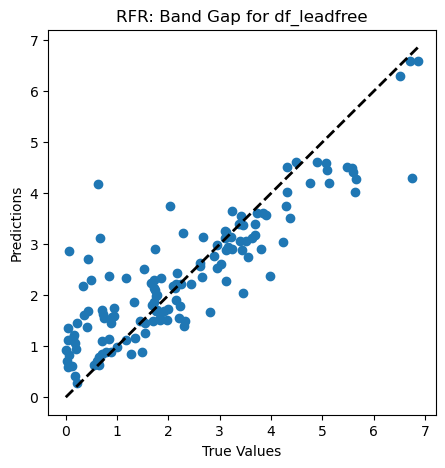

Name:  df_leadfree
RMSE:  0.7420029812131758
RMAE:  0.6103038905109492
R2_train:  0.9619636319576683
R2_test:  0.7372530315295407
Features:                        Feature  Importance
29      density_of_solid_mean    0.204841
1   formation_energy_per_atom    0.194785
39                       SOAP    0.191561
8                   group_std    0.040279
0           energy_above_hull    0.035615




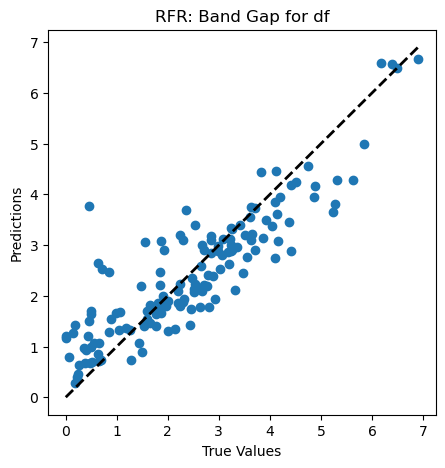

Name:  df
RMSE:  0.5462588210079167
RMAE:  0.5496710069930074
R2_train:  0.9613190092866384
R2_test:  0.7688741293680643
Features:                        Feature  Importance
29      density_of_solid_mean    0.211882
39                       SOAP    0.195990
1   formation_energy_per_atom    0.172294
0           energy_above_hull    0.042483
8                   group_std    0.036529




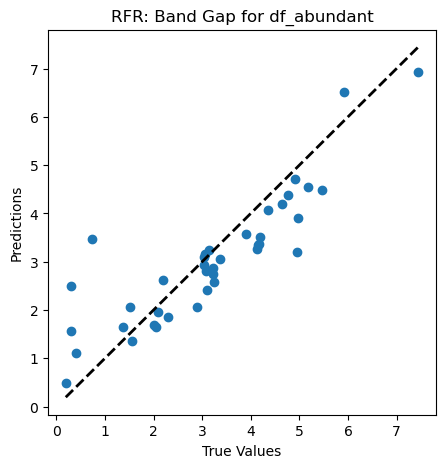

Name:  df_abundant
RMSE:  0.6949913090078466
RMAE:  0.6213680000000004
R2_train:  0.9534117976872253
R2_test:  0.7498113585683436
Features:                        Feature  Importance
39                       SOAP    0.177422
1   formation_energy_per_atom    0.162760
12           mendeleev_no_std    0.111364
29      density_of_solid_mean    0.105893
8                   group_std    0.086707




In [59]:
for df in list_big_df:
    train_and_test_rfr(df, 0.1, True, True )
    # df.print()

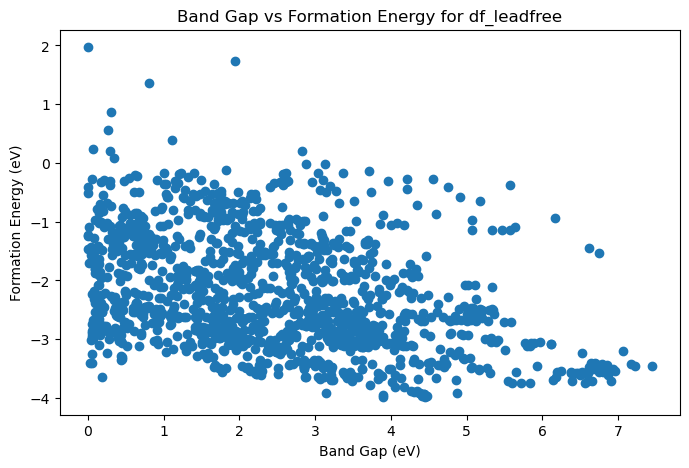

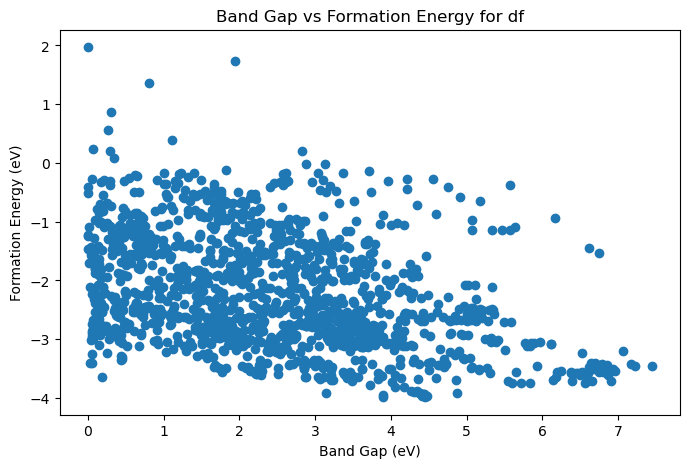

In [152]:
def plot_bg_vs_FE (big_df_list):
    # expects a list of big_df objects
    # plots the band gap vs formation energy for each dataframe in the list
    # saves the plot as a png file
    # returns nothing

    for df in big_df_list:
        plt.figure(figsize=(8, 5))
        plt.scatter( df.df["band_gap"],df.df["formation_energy_per_atom"])
        plt.ylabel("Formation Energy (eV)")
        plt.xlabel("Band Gap (eV)")
        plt.title("Band Gap vs Formation Energy for " + df.name)
        plt.savefig(df.name + "_band_gap_vs_FE.png")
        plt.show()


plot_bg_vs_FE(list_big_df)






In [58]:

def store_RMAE_RMSE(big_df_list):
    df = pd.DataFrame(columns=["dataset", "RMSE", "RMAE"])
    
    for df_temp in big_df_list:
        row = pd.DataFrame([{
            "dataset": df_temp.name,
            "RMSE": df_temp.RMSE,
            "RMAE": df_temp.RMAE
        }])
        df = pd.concat([df, row], ignore_index=True)

    return df


df_rfr_evaluations = store_RMAE_RMSE(list_big_df)
print(df_rfr_evaluations)

       dataset      RMSE      RMAE
0  df_leadfree  0.774025  0.620456
1           df  0.518140  0.537927
2  df_abundant  0.676395  0.608857


In [172]:
from sklearn.experimental import enable_halving_search_cv  # Required for HalvingGridSearchCV
from sklearn.model_selection import HalvingGridSearchCV, KFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import numpy as np

def tune_random_forest_with_halving_cv(big_df_temp):
    "Input: custom class big_df with X_tran and y_train"
    "Output: tunes the random forest regressor with HalvingGridSearchCV and returns the best parameters and the RMSE"

    # Define cross-validation strategy
    cv = KFold(n_splits=5, shuffle=True, random_state=42)

    # Define parameter grid
    param_grid = {
        'n_estimators': [100, 200],
        'max_depth': [None, 10, 20],
        'min_samples_split': [2, 5],
    }

    # Set up the HalvingGridSearchCV
    search = HalvingGridSearchCV(
        RandomForestRegressor(random_state=0),
        param_grid,
        cv=cv,
        factor=2,
        scoring='neg_mean_squared_error',
        verbose=1,
        n_jobs=-1
    )

    # Fit model
    search.fit(big_df_temp.X_train, big_df_temp.y_train)

    # Save best estimator and metrics to big_df_temp
    best_model = search.best_estimator_
    y_pred = best_model.predict(big_df_temp.X_test)
    rmse = mean_squared_error(big_df_temp.y_test, y_pred, squared=False)

    print(f"🔍 Best hyperparameters for {big_df_temp.name}:")
    print(search.best_params_)
    print(f"📉 RMSE on full data with best params: {rmse:.4f}")
    
    return search.best_params_, rmse


# best_params, rmse = tune_random_forest_with_halving_cv(list_big_df[1])
# print(f"Best parameters for {list_big_df[1].name}: {best_params}")
# print(f"RMSE: {rmse:.4f}")
# Example usage
for df in list_big_df:
    best_params, rmse = tune_random_forest_with_halving_cv(df)
    print(f"Best parameters for {df.name}: {best_params}")
    print(f"RMSE: {rmse:.4f}")


n_iterations: 4
n_required_iterations: 4
n_possible_iterations: 4
min_resources_: 153
max_resources_: 1227
aggressive_elimination: False
factor: 2
----------
iter: 0
n_candidates: 12
n_resources: 153
Fitting 5 folds for each of 12 candidates, totalling 60 fits
----------
iter: 1
n_candidates: 6
n_resources: 306
Fitting 5 folds for each of 6 candidates, totalling 30 fits
----------
iter: 2
n_candidates: 3
n_resources: 612
Fitting 5 folds for each of 3 candidates, totalling 15 fits
----------
iter: 3
n_candidates: 2
n_resources: 1224
Fitting 5 folds for each of 2 candidates, totalling 10 fits
🔍 Best hyperparameters for df_leadfree:
{'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 200}
📉 RMSE on full data with best params: 0.8798
Best parameters for df_leadfree: {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 200}
RMSE: 0.8798
n_iterations: 4
n_required_iterations: 4
n_possible_iterations: 4
min_resources_: 160
max_resources_: 1281
aggressive_elimination: False
factor: 

🔍 Best hyperparameters for df_leadfree:
{'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 200}
📉 RMSE on full data with best params: 0.8798
Best parameters for df_leadfree: {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 200}
RMSE: 0.8798

🔍 Best hyperparameters for df:
{'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 200}
📉 RMSE on full data with best params: 0.7198
Best parameters for df: {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 200}
RMSE: 0.7198

🔍 Best hyperparameters for df_abundant:
{'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
📉 RMSE on full data with best params: 0.8224
Best parameters for df_abundant: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
RMSE: 0.8224

In [49]:
def train_and_test_rfr_2(big_df_temp, test_size = 0.1, store = True, plot = False , max_depth = None, n_estimators = 200):

    "Same as above, but with the option to set the max depth and n_estimators"


   



    big_df_temp.X = big_df_temp.df.select_dtypes(include=[np.number]).drop(columns=["band_gap"])

    big_df_temp.y = np.asarray(big_df_temp.df["band_gap"]) 
        # Split the data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(big_df_temp.X, big_df_temp.y, test_size=test_size, random_state=9)
    
    # Create a Random Forest Regressor model
    "These are the values from the paper"
    rfr = GridSearchCV (RandomForestRegressor(),{'max_depth':max_depth,'n_estimators':n_estimators, 'random_state':[0],}, cv=5)
    
    # Fit the model to the training data
    rfr.fit(X_train, y_train)
    
    # Make predictions on the test set
    y_predicted = rfr.predict(X_test)
    #plot the predicted values against the true values and add a line for the ideal prediction
    

    "Plots the predicted values against the true values"
    
    if plot: 
        plt.figure(figsize=(5, 5))
        plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
        plt.scatter(y_test, y_predicted)
        plt.xlabel("True Values")
        plt.ylabel("Predictions")
        plt.title("RFR: Band Gap for " + big_df_temp.name)
        plt.savefig(big_df_temp.name + "_RFR_band_gap.png")
        plt.show()


    "look at the feature importance"

    importances = rfr.best_estimator_.feature_importances_
    feature_names = X_train.columns

    # DataFrame with individual importances
    importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
    })

    # Aggregate all soap_X components into one "SOAP" feature
    soap_start_index = 39  # index where soap columns start
    soap_columns = feature_names[soap_start_index:]

    #Sum their importance
    soap_importance = importance_df[importance_df['Feature'].isin(soap_columns)]['Importance'].sum()

    # Add it as a row in the dataframe
    high_level_importance_df = importance_df[~importance_df['Feature'].isin(soap_columns)].copy()
    high_level_importance_df = pd.concat([
    high_level_importance_df,
    pd.DataFrame([{'Feature': 'SOAP', 'Importance': soap_importance}])
    ], ignore_index=True)

    # Sort and show
    high_level_importance_df = high_level_importance_df.sort_values(by='Importance', ascending=False)

    # print("Grouped Feature Importances for " + big_df_temp.name)
    # print(high_level_importance_df.head(5))

    r2_score = rfr.score(X_train, y_train)
    
    r2_score1 = rfr.score(X_test, y_test)
    rmse = mean_squared_error(y_test, y_predicted)
    rmae = mean_absolute_error(y_test, y_predicted)
    if store:
        big_df_temp.features = high_level_importance_df
        big_df_temp.R2_train = r2_score
        big_df_temp.R2_test = r2_score1
        big_df_temp.RMSE = rmse
        print ("RMSE: ", rmse)
        print(big_df_temp.RMSE)
        big_df_temp.RMAE = rmae

        big_df_temp.X_train = X_train
        big_df_temp.X_test = X_test
        big_df_temp.y_train = y_train
        big_df_temp.y_test = y_test
        big_df_temp.print()
        return
    else: 
    
        # print("RMSE: ", rmse)
        # print("RMAE: ", rmae)
    
        return rmse
    
    
   
# for df in list_big_df:


In [ ]:
train_and_test_rfr_2(list_big_df[1], 0.1, True, True, max_depth= 20, n_estimators= 200)

In [22]:
" repeated LOOCV"
# Parameter grid for hyperparameter search

def get_best_hyperparameters(big_df_temp,n_estimators, max_depth):
    
    X_train, X_test, y_train, y_test = train_test_split(big_df_temp.X, big_df_temp.y, test_size=0.1, random_state=9)
    p_grid = {"n_estimators": n_estimators, "max_depth": max_depth}
    # Initialise the Random Forest classifier
    rf = RandomForestRegressor(random_state=22)

    # Initialise KFold
    kf = KFold(n_splits=5, shuffle=True, random_state=12)

    # GridSearch CV
    gs = GridSearchCV(estimator=rf, param_grid=p_grid, cv=kf, scoring='neg_mean_squared_error')

    gs.fit(X_train, y_train)
    

    # Define model with best hyperparameters and print them
    model = gs.best_estimator_
    y_pred = model.predict(big_df_temp.X_test)
    rmse = mean_squared_error(big_df_temp.y_test, y_pred, squared=False)
    print(f"Hyperparameters: {gs.best_params_}\n")
    print(f"📉 RMSE on full data with best params: {rmse:.4f}")
    return model


# p_grid = {"n_estimators": [10,15,30], "max_depth": [None,10,20]}
# Hyperparameters: {'max_depth': 20, 'n_estimators': 30}


n_estimators = [10,100,200]
max_depth = [None,10,20,30]

model = get_best_hyperparameters(list_big_df[1],n_estimators , max_depth)

Hyperparameters: {'max_depth': 20, 'n_estimators': 200}

📉 RMSE on full data with best params: 0.7202


df: Hyperparameters: {'max_depth': 20, 'n_estimators': 200}

📉 RMSE on full data with best params: 0.7202

-> got the same hyperparameters as with the halving grid search, so from now on I will use that

This took 100min for only the df dataframe, if i have time I will also test it for the other 2 dataframes but for now I will assume that for them the repeated CV yields the same hyperparamters as the Havling


In [27]:
def evaluate_model_with_cv(model,big_df_temp, random_state):
    """
    Evaluate a model using 5-fold cross-validation and return performance metrics.

    Parameters:
        model: The model to evaluate
        X: Feature matrix
        y: Target vector
        random_state: Random seed for reproducibility

    Returns:
        Dictionary with performance metrics and arrays of per-fold metrics
    """
    # Initialize KFold
    kf = KFold(n_splits=5, shuffle=True, random_state=random_state)

    # Lists to store metrics
    metrics = {
        'RMSE': [],
        'RMAE': [],
        'R2_train': [],
        'R2_test': [],

    }


    # Iterate over folds
    for train_index, test_index in kf.split(big_df_temp.X):
        # Use .iloc to index rows by position
        X_train_fold = big_df_temp.X.iloc[train_index]
        X_test_fold = big_df_temp.X.iloc[test_index]
        y_train_fold = big_df_temp.y[train_index]
        y_test_fold = big_df_temp.y[test_index]

        # Train model
        model.fit(X_train_fold, y_train_fold)

        # Predict
        y_pred_fold = model.predict(X_test_fold)
        

        # Calculate metrics
        metrics['RMSE'].append(mean_squared_error(y_test_fold, y_pred_fold))
        metrics['RMAE'].append(mean_absolute_error(y_test_fold, y_pred_fold))
        metrics['R2_train'].append(model.score(X_train_fold, y_train_fold))
        metrics['R2_test'].append(model.score(X_test_fold, y_test_fold))





    # Print metrics
    metric_display_names = {
        'RMSE': 'RMSE',
        'RMAE': 'RMAE',
        'R2_train': 'R2_train',
        'R2_test': 'R2_test',
        
    }
    for metric_name, values in metrics.items():
        display_name = metric_display_names[metric_name]
        print(f"Average {display_name}: {np.mean(values):.4f} \t and std err: {stats.sem(values):.4f}")

    return metrics

In [28]:
metrics_rfr = evaluate_model_with_cv(model, list_big_df[1], random_state=42)

Average RMSE: 0.6762 	 and std err: 0.0278
Average RMAE: 0.5836 	 and std err: 0.0097
Average R2_train: 0.9617 	 and std err: 0.0006
Average R2_test: 0.7292 	 and std err: 0.0132


Average RMSE: 0.6762 	 and std err: 0.0278
Average RMAE: 0.5836 	 and std err: 0.0097
Average R2_train: 0.9617 	 and std err: 0.0006
Average R2_test: 0.7292 	 and std err: 0.0132

It seems that the chosen hyper parameters are stable

In [63]:
import copy
optimized_params_df = copy.deepcopy(list_big_df)

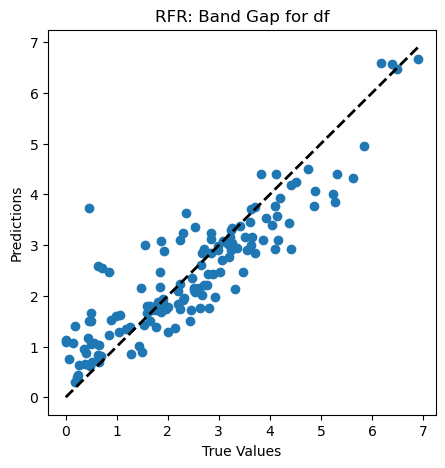

RMSE:  0.518139603736531
0.518139603736531
Name:  df
RMSE:  0.518139603736531
RMAE:  0.5379272258011113
R2_train:  0.9615316954943507
R2_test:  0.7807715639236217
Features:                        Feature  Importance
29      density_of_solid_mean    0.210693
39                       SOAP    0.197396
1   formation_energy_per_atom    0.168499
0           energy_above_hull    0.041376
13        iupac_ordering_mean    0.040112




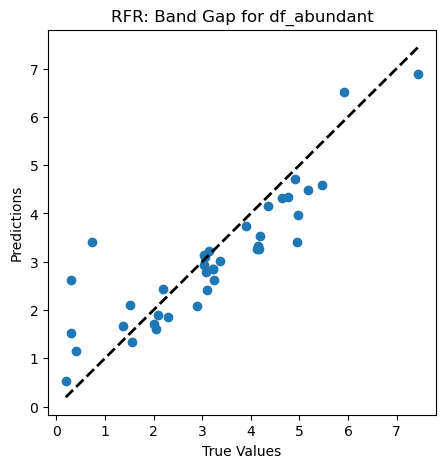

RMSE:  0.6763946216650009
0.6763946216650009
Name:  df_abundant
RMSE:  0.6763946216650009
RMAE:  0.6088574358974368
R2_train:  0.9564919628775405
R2_test:  0.7565059457971794
Features:                        Feature  Importance
39                       SOAP    0.176209
1   formation_energy_per_atom    0.165057
12           mendeleev_no_std    0.112709
29      density_of_solid_mean    0.105804
8                   group_std    0.090652




In [64]:
# train_and_test_rfr_2(optimized_params_df[0], 0.1, store = True, plot = True, max_depth= [20], n_estimators= [200])
train_and_test_rfr_2(optimized_params_df[1], 0.1, True, True, max_depth= [20], n_estimators= [200])
train_and_test_rfr_2(optimized_params_df[2], 0.1, True, True, max_depth= [None], n_estimators= [200])

So from this i can see that the hyperparameters for df and df_abundant, imporved upon my optimization. wierdly enough, for df_leadfree this is not the case, the original max_depth = None and default n_estimators = 200 performed better. So i retrain the model for df_leadfree with the initial hyper parameters 

For some reason these are not the same values as before although the random states are the same, so my guess is taht n_estimtors is not the default as expected but rather some other value. Work on this later.

In [ ]:
# optimized_params_df[0] = copy.deepcopy((list_big_df[0]))

In [65]:
df_rfr_optimized = store_RMAE_RMSE(optimized_params_df)
print(df_rfr_optimized)

       dataset      RMSE      RMAE
0  df_leadfree  0.742003  0.610304
1           df  0.518140  0.537927
2  df_abundant  0.676395  0.608857


       dataset      RMSE      RMAE
0  df_leadfree  0.742003  0.610304
1           df  0.518140  0.537927
2  df_abundant  0.676395  0.608857

In [ ]:
def plot_y_hist(list_big_df):
    for big_df_temp in list_big_df:
        plt.figure(figsize=(8, 5))
        plt.hist(big_df_temp.df["band_gap"], bins=50)
        plt.xlabel("Band Gap (eV)")
        plt.title("Band Gap Distribution for " + big_df_temp.name)
        plt.savefig(big_df_temp.name + "_band_gap_histogram.png")
        plt.show()


        plt.figure(figsize=(8, 5))
        plt.hist(big_df_temp.df["energy_above_hull"], bins=50)
        plt.xlabel("Energy Above Hull (eV)")
        plt.title("Energy above Hull Distribution for " + big_df_temp.name)
        plt.savefig(big_df_temp.name + "_energy_above_hull_histogram.png")
        plt.show()
    print("plot done")
    return



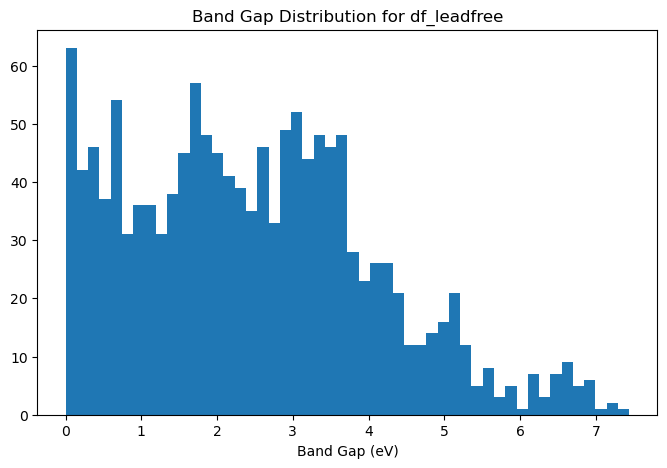

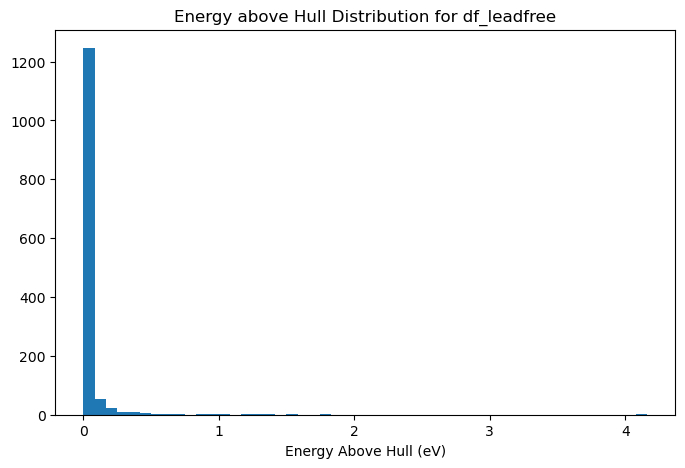

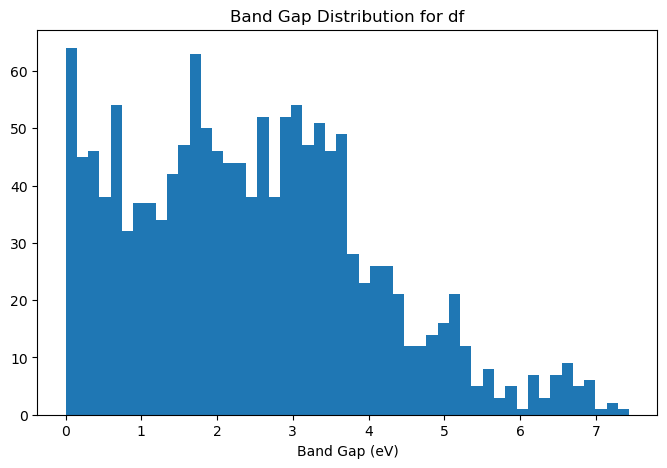

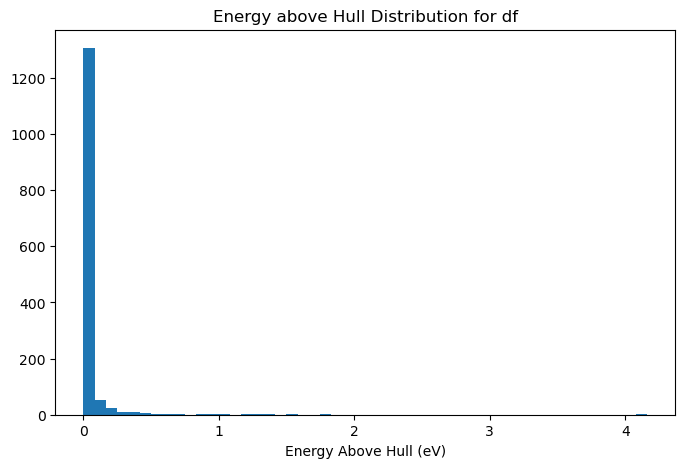

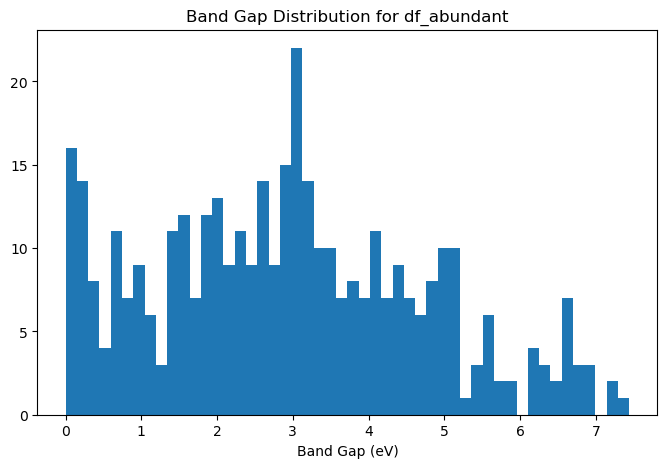

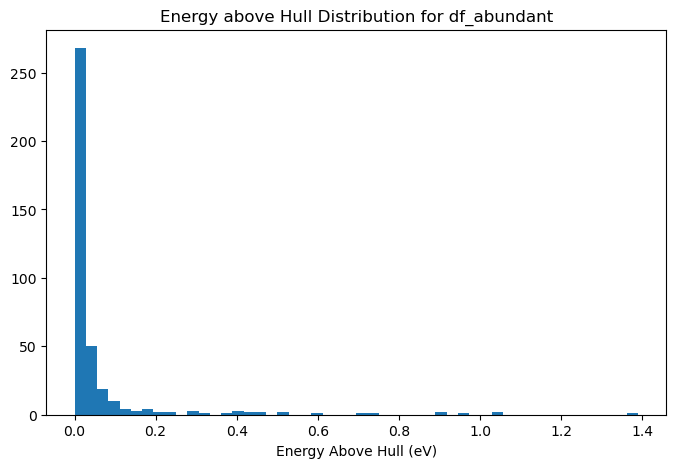

plot done


In [36]:
plot_y_hist(optimized_params_df)

Seems like we dont really have outliers

In [138]:
from sklearn.decomposition import PCA
import umap
import matplotlib.pyplot as plt
import sklearn.datasets
import umap.plot


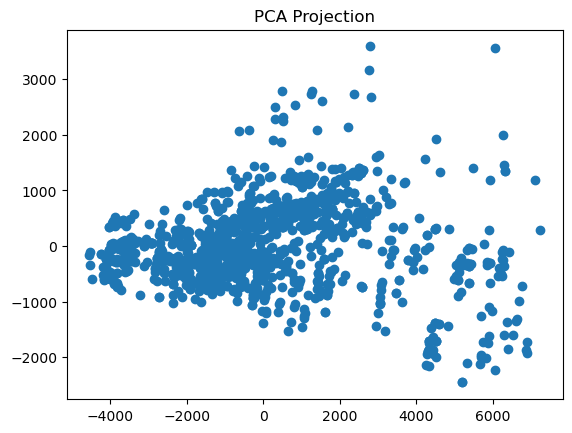

/opt/anaconda3/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


<Axes: >

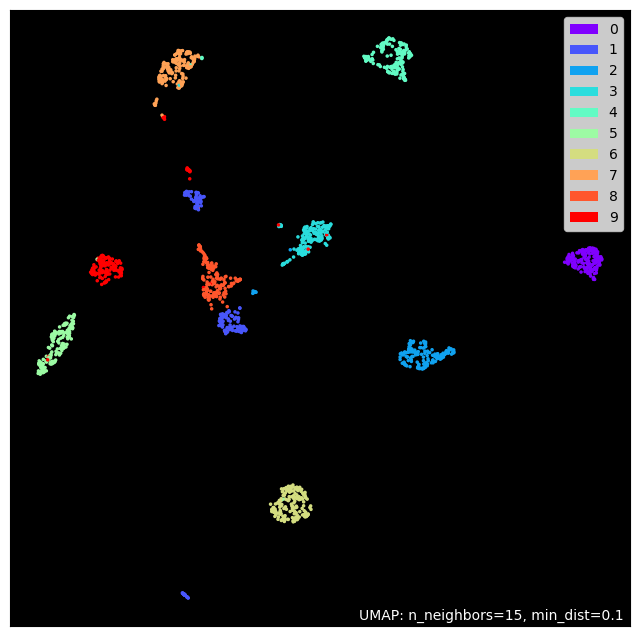

In [153]:

# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train)

plt.scatter(X_pca[:, 0], X_pca[:, 1])
plt.title("PCA Projection")
plt.show()

# UMAP
reducer = umap.UMAP(n_components=2, random_state=42)
X_umap = reducer.fit_transform(X_train)
pendigits = sklearn.datasets.load_digits()
mnist = sklearn.datasets.fetch_openml('mnist_784')
fmnist = sklearn.datasets.fetch_openml('Fashion-MNIST')
mapper = umap.UMAP().fit(pendigits.data)
umap.plot.points(mapper, labels=pendigits.target,theme='fire')  


# plt.scatter(X_umap[:, 0], X_umap[:, 1])
# plt.title("UMAP Projection")
# plt.show()


In [118]:
from sklearn.linear_model import RidgeCV, LassoCV, ElasticNetCV

# Ridge
ridge = RidgeCV(alphas=[0.01, 0.1, 1.0, 10.0], cv=5)
ridge.fit(X_train, y_train)

# Lasso
lasso = LassoCV(alphas=[0.01, 0.1, 1.0, 10.0], cv=5)
lasso.fit(X_train, y_train)

# ElasticNet
elastic = ElasticNetCV(l1_ratio=[.1, .5, .7, .9, .95, 1], cv=5)
elastic.fit(X_train, y_train)

from sklearn.metrics import mean_squared_error, r2_score

# Evaluate Ridge
ridge_preds = ridge.predict(X_test)
print("Ridge R²:", r2_score(y_test, ridge_preds))
print("Ridge RMSE:", mean_squared_error(y_test, ridge_preds, squared=False))

# Evaluate Lasso
lasso_preds = lasso.predict(X_test)
print("Lasso R²:", r2_score(y_test, lasso_preds))
print("Lasso RMSE:", mean_squared_error(y_test, lasso_preds, squared=False))

# Evaluate ElasticNet
elastic_preds = elastic.predict(X_test)
print("ElasticNet R²:", r2_score(y_test, elastic_preds))
print("ElasticNet RMSE:", mean_squared_error(y_test, elastic_preds, squared=False))



/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:664: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 444.60832093595405, tolerance: 0.25665497864235953
  model = cd_fast.enet_coordinate_descent_gram(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:664: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 402.74093813543413, tolerance: 0.26376063734131133
  model = cd_fast.enet_coordinate_descent_gram(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:664: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 487.1431425194679, tolerance: 0.25250419737984775
  model = cd_fast.enet_coordinate_descent_gram(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descen

Ridge R²: 0.5506245048825857
Ridge RMSE: 1.0305750986376598
Lasso R²: 0.5016951409414686
Lasso RMSE: 1.0852318032667903
ElasticNet R²: 0.1750573856902684
ElasticNet RMSE: 1.396325987154782


/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [130]:
ridge = ElasticNetCV(cv=5).fit(X_train, y_train)

# Select only non-zero coefficient features
selected_features = X_train.columns[ridge.coef_ != 0]

print("Selected features:", selected_features)

X_train_ridge = X_train[selected_features]
y_train_ridge = y_train
X_test_ridge = X_test[selected_features]
rfr = GridSearchCV (RandomForestRegressor(),{'max_depth':[None], 'random_state':[0],}, cv=5)
rfr.fit(X_train_ridge, y_train_ridge)
rfr_score = rfr.score(X_train_ridge,y_train_ridge)
rfr_score1 = rfr.score(X_test_ridge,y_test)
y_predicted8 = rfr.predict(X_test_ridge)
print('RFR Model| R2 sq on train set: %.4f'% rfr_score)
print('RFR Model| R2 sq on test set: %.4f'% rfr_score1)
print('RFR Model| MSE on test set: %.4f'% mean_squared_error(y_test, y_predicted8))
print('RFR Model| MAE on test set: %.4f'% mean_absolute_error(y_test, y_predicted8))

Selected features: Index(['atom_mass_mean', 'atom_mass_std', 'mendeleev_no_mean',
       'iupac_ordering_mean', 'density_of_solid_mean', 'density_of_solid_std',
       'evaporation_heat_std'],
      dtype='object')
RFR Model| R2 sq on train set: 0.9162
RFR Model| R2 sq on test set: 0.5136
RFR Model| MSE on test set: 1.1497
RFR Model| MAE on test set: 0.8151


This is the score without any regularisation 

RFR Model| R2 sq on train set: 0.9594
RFR Model| R2 sq on test set: 0.7289
RFR Model| MSE on test set: 0.6408
RFR Model| MAE on test set: 0.6078

and this is it with 

RFR Model| R2 sq on train set: 0.9162
RFR Model| R2 sq on test set: 0.5136
RFR Model| MSE on test set: 1.1497
RFR Model| MAE on test set: 0.8151

clearly the regularisation with lasso/elasticnet made the model worse

regularization with ridge did not cahnge a thing 
